In [1]:
import pandas as pd

from metrics import load_validation_data

In [2]:
validation_data = load_validation_data()
validation_data = validation_data[validation_data.reference != "unknown"]
validation_data

,name,geometry,reference,modified_time,id,wofl
0,dry_land,POINT (-823924.892 -913611.431),dry,1.745444e+09,LT50990661997224ASA00,dry
1,dry_land,POINT (-845768.908 -1007313.152),dry,1.745444e+09,LT50990661997224ASA00,dry
2,dry_land,POINT (-927347.324 -887321.284),dry,1.745444e+09,LT50990661997224ASA00,dry
3,dry_land,POINT (-795302.594 -991082.866),dry,1.745444e+09,LT50990661997224ASA00,dry
4,dry_land,POINT (-955273.175 -929894.872),dry,1.745444e+09,LT50990661997224ASA00,dry
...,...,...,...,...,...,...
45,wet_ocean,POINT (-618932.627 1473394.902),wet,1.745444e+09,LE71000512010035EDC00,wet
46,wet_ocean,POINT (-568528.667 1521897.782),wet,1.745444e+09,LE71000512010035EDC00,wet
47,wet_ocean,POINT (-590759.593 1503868.41),wet,1.745444e+09,LE71000512010035EDC00,wet
48,wet_ocean,POINT (-594695.71 1479946.381),wet,1.745444e+09,LE71000512010035EDC00,wet


In [5]:
validation_data["combined"] = validation_data.wofl + "_" + validation_data.reference
validation_data.to_file("validation_data.gpkg")

In [4]:
pd.crosstab(validation_data.wofl, validation_data.reference, normalize="index").round(2)

reference,cloud,dry,wet
wofl,,,
dry,0.25,0.46,0.30
wet,0.09,0.02,0.88


In [10]:
pd.crosstab(validation_data.name, validation_data.reference, normalize="index").round(2)

reference,cloud,dry,wet
name,,,
dry_land,0.09,0.91,0.00
dry_ocean,0.41,0.00,0.59
wet_land,0.06,0.07,0.87
wet_ocean,0.11,0.00,0.89


In [9]:
land_only = validation_data[validation_data.name.isin(["dry_land", "wet_land"])]
pd.crosstab(land_only.name, land_only.reference, normalize="index").round(2)

reference,cloud,dry,wet
name,,,
dry_land,0.09,0.91,0.00
wet_land,0.06,0.07,0.87


In [12]:
validation_data["order"] = validation_data.modified_time.factorize()[0] + 1
validation_data["acc"] = validation_data.wofl == validation_data.reference

In [43]:
import plotnine as pn

acc_by_tile = validation_data.groupby("order").agg({"acc": ["mean", "sum", "count"]})
acc_by_tile.columns = ["_".join(col) for col in acc_by_tile.columns]

acc_by_tile = acc_by_tile.reset_index().assign(
    cum_sum=acc_by_tile.acc_sum.cumsum(),
    cum_count=acc_by_tile.acc_count.cumsum(),
    cum_acc=lambda x: x.cum_sum / x.cum_count,
)

acc_by_tile

,order,acc_mean,acc_sum,acc_count,cum_sum,cum_count,cum_acc
0,1,1.000000,91,91,NaN,NaN,NaN
1,2,0.602273,53,88,91.0,91.0,1.000000
2,3,0.616438,45,73,144.0,179.0,0.804469
3,4,0.581081,43,74,189.0,252.0,0.750000
4,5,0.657534,48,73,232.0,326.0,0.711656
5,6,0.731959,71,97,280.0,399.0,0.701754
6,7,0.687500,55,80,351.0,496.0,0.707661
7,8,0.637681,44,69,406.0,576.0,0.704861
8,9,0.311688,24,77,450.0,645.0,0.697674
9,10,0.722222,65,90,474.0,722.0,0.656510


/home/jesse/Projects/D4D/dep-wofs/venv/lib/python3.10/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


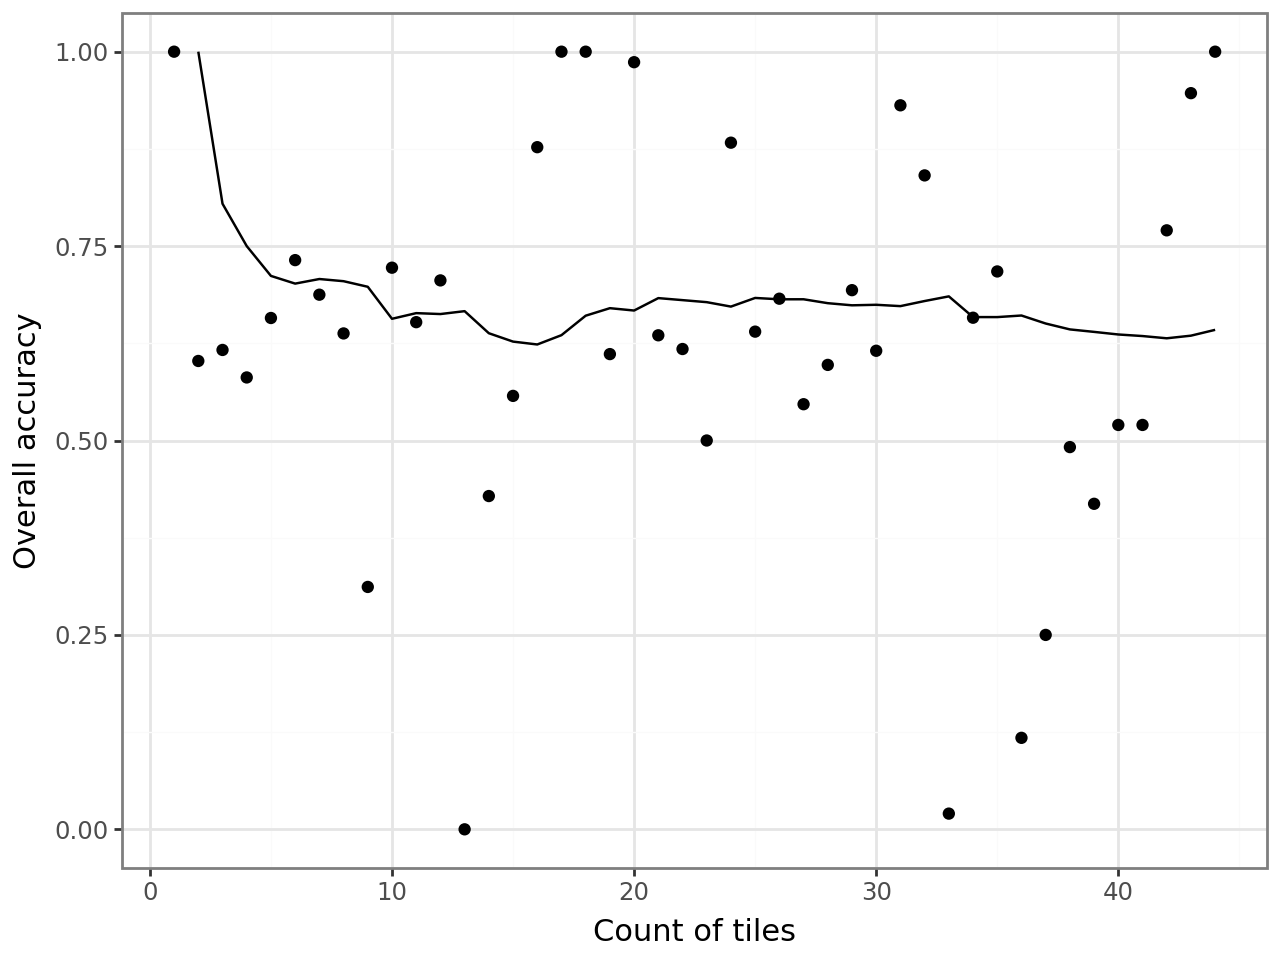

In [46]:
(
    pn.ggplot(acc_by_tile, pn.aes(x="order"))
    + pn.geom_point(pn.aes(y="acc_mean"))
    + pn.geom_line(pn.aes(y="cum_acc"))
    + pn.xlab("Count of tiles")
    + pn.ylab("Overall accuracy")
    + pn.theme_bw()
)